# Logistic Regression

---

## Table of Contents
1. [From Linear to Logistic — the core problem](#1-from-linear-to-logistic)
2. [The Sigmoid Function](#2-the-sigmoid-function)
3. [The Model & Decision Boundary](#3-the-model--decision-boundary)
4. [Loss Function — Binary Cross-Entropy](#4-loss-function--binary-cross-entropy)
5. [Maximum Likelihood Estimation](#5-maximum-likelihood-estimation)
6. [Gradient Descent on Log-Loss](#6-gradient-descent-on-log-loss)
7. [Multiclass — Softmax](#7-multiclass--softmax)
8. [Regularisation](#8-regularisation)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.special import softmax as scipy_softmax
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#ccc',
    'xtick.color': '#888', 'ytick.color': '#888', 'text.color': '#eee',
    'grid.color': '#2a2a2a', 'grid.linewidth': 0.8,
    'font.family': 'monospace', 'axes.titlesize': 12, 'axes.labelsize': 11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'

---
## 1. From Linear to Logistic

Linear regression predicts $\hat{y} = X\theta \in (-\infty, +\infty)$. For binary classification we need $\hat{y} \in [0,1]$ — a **probability**.

The naive fix — thresholding $X\theta$ at 0.5 — fails because:
- The output is unbounded: $X\theta$ can be 100 or $-500$
- Least squares loss is the wrong objective for probabilities
- The decision boundary would shift arbitrarily with outliers

The fix: pass $X\theta$ through a function that **squashes** any real number to $(0,1)$. That function is the **sigmoid**.

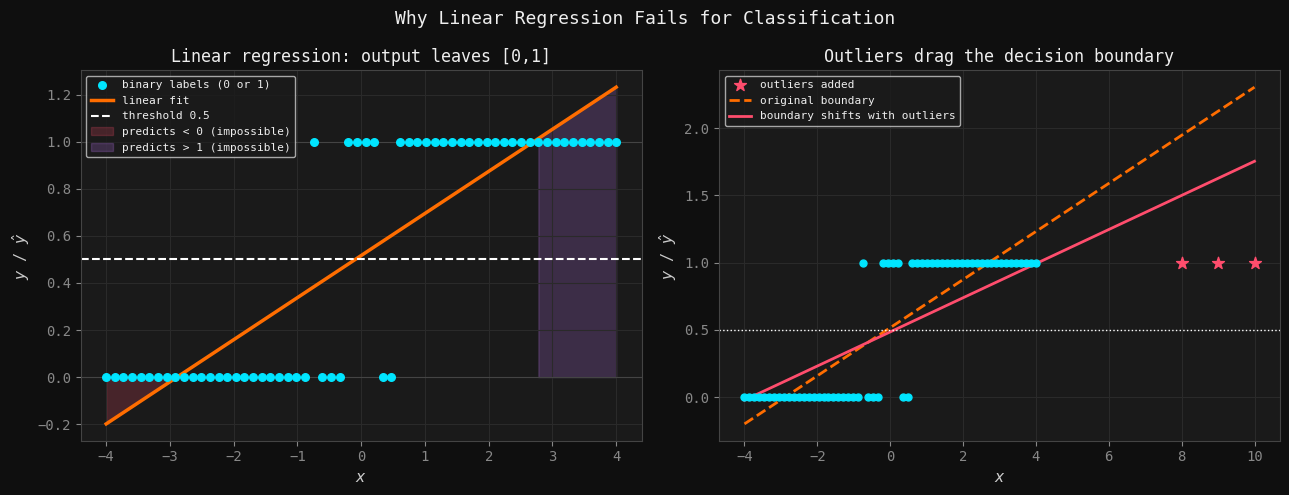

In [2]:
np.random.seed(0)
n = 60
x1d = np.linspace(-4, 4, n)
y1d = (x1d + np.random.normal(0, 0.4, n) > 0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Why Linear Regression Fails for Classification', fontsize=13)

# Linear regression fit on binary labels
ax = axes[0]
coef = np.polyfit(x1d, y1d, 1)
y_lin = np.polyval(coef, x1d)
ax.scatter(x1d, y1d, color=ACCENT, s=30, zorder=5, label='binary labels (0 or 1)')
ax.plot(x1d, y_lin, color=ORANGE, lw=2.5, label='linear fit')
ax.axhline(0.5, color='white', lw=1.5, linestyle='--', label='threshold 0.5')
ax.axhline(0,   color='#444',  lw=0.8)
ax.axhline(1,   color='#444',  lw=0.8)
ax.fill_between(x1d, y_lin, where=(y_lin < 0), color=RED,    alpha=0.2, label='predicts < 0 (impossible)')
ax.fill_between(x1d, y_lin, where=(y_lin > 1), color=PURPLE, alpha=0.2, label='predicts > 1 (impossible)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$ / $\\hat{y}$')
ax.set_title('Linear regression: output leaves [0,1]')
ax.legend(fontsize=8); ax.grid(True)

# Outlier effect
ax = axes[1]
x_out = np.append(x1d, [8, 9, 10])
y_out = np.append(y1d, [1, 1, 1])
coef2 = np.polyfit(x_out, y_out, 1)
y_lin2 = np.polyval(coef2, x_out)
ax.scatter(x1d, y1d, color=ACCENT, s=25, zorder=5)
ax.scatter([8,9,10], [1,1,1], color=RED, s=80, zorder=6, marker='*', label='outliers added')
ax.plot(x_out, np.polyval(coef,  x_out), color=ORANGE, lw=2, linestyle='--', label='original boundary')
ax.plot(x_out, y_lin2,                   color=RED,    lw=2, label='boundary shifts with outliers')
ax.axhline(0.5, color='white', lw=1, linestyle=':')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$ / $\\hat{y}$')
ax.set_title('Outliers drag the decision boundary')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('img/lr01_motivation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. The Sigmoid Function

The **sigmoid** (logistic function) maps any real number to $(0,1)$:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

Key properties:
- $\sigma(0) = 0.5$
- $\sigma(z) \to 1$ as $z \to +\infty$, $\sigma(z) \to 0$ as $z \to -\infty$
- **Derivative**: $\sigma'(z) = \sigma(z)(1-\sigma(z))$ — elegant and cheap to compute
- **Symmetry**: $\sigma(-z) = 1 - \sigma(z)$
- **Odds interpretation**: $\frac{\sigma(z)}{1-\sigma(z)} = e^z$, so $z = \log\frac{p}{1-p}$ is the **log-odds** (logit)

The logit function is the inverse of the sigmoid:
$$\text{logit}(p) = \log\frac{p}{1-p} = \sigma^{-1}(p)$$

Logistic regression is **linear in log-odds space**. The model assumes:
$$\log\frac{P(y=1|x)}{P(y=0|x)} = \theta_0 + \theta_1 x_1 + \cdots + \theta_p x_p = x^\top\theta$$

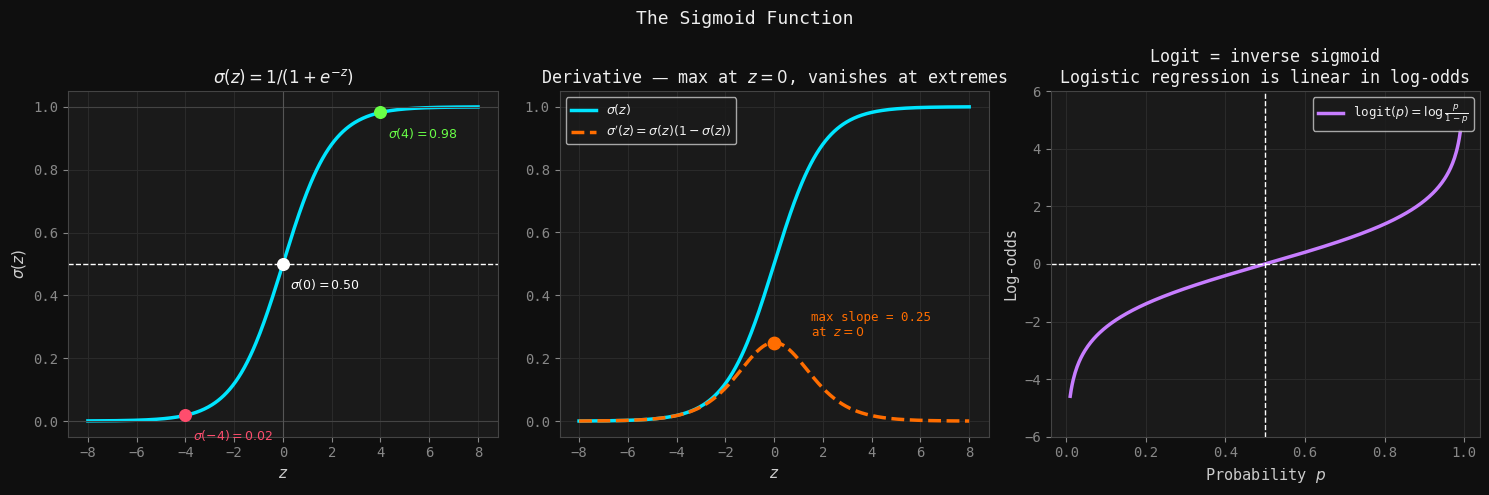

In [3]:
def sigmoid(z): return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('The Sigmoid Function', fontsize=13)

# Sigmoid shape
ax = axes[0]
ax.plot(z, sigmoid(z), color=ACCENT, lw=2.5)
ax.axhline(0.5, color='white', lw=1, linestyle='--')
ax.axhline(0,   color='#444',  lw=0.8)
ax.axhline(1,   color='#444',  lw=0.8)
ax.axvline(0,   color='#555',  lw=0.8)
# Annotate key values
for z_pt, color in [(-4, RED), (0, 'white'), (4, GREEN)]:
    ax.scatter(z_pt, sigmoid(z_pt), color=color, s=70, zorder=5)
    ax.annotate(f'$\\sigma({z_pt})={sigmoid(z_pt):.2f}$',
                xy=(z_pt, sigmoid(z_pt)), xytext=(z_pt+0.3, sigmoid(z_pt)-0.08),
                color=color, fontsize=9)
ax.set_xlabel('$z$'); ax.set_ylabel('$\\sigma(z)$')
ax.set_title('$\\sigma(z) = 1/(1+e^{-z})$'); ax.grid(True)

# Derivative
ax = axes[1]
deriv = sigmoid(z) * (1 - sigmoid(z))
ax.plot(z, sigmoid(z), color=ACCENT,  lw=2.5, label='$\\sigma(z)$')
ax.plot(z, deriv,      color=ORANGE, lw=2.5, linestyle='--', label="$\\sigma'(z) = \\sigma(z)(1-\\sigma(z))$")
ax.scatter(0, 0.25, color=ORANGE, s=80, zorder=5)
ax.annotate('max slope = 0.25\nat $z=0$', xy=(0, 0.25), xytext=(1.5, 0.27), color=ORANGE, fontsize=9)
ax.set_xlabel('$z$'); ax.set_title('Derivative — max at $z=0$, vanishes at extremes')
ax.legend(fontsize=9); ax.grid(True)

# Logit (inverse)
ax = axes[2]
p_vals = np.linspace(0.01, 0.99, 400)
logit  = np.log(p_vals / (1 - p_vals))
ax.plot(p_vals, logit, color=PURPLE, lw=2.5, label='logit$(p) = \\log\\frac{p}{1-p}$')
ax.axhline(0, color='white', lw=1, linestyle='--')
ax.axvline(0.5, color='white', lw=1, linestyle='--')
ax.set_xlabel('Probability $p$'); ax.set_ylabel('Log-odds')
ax.set_title('Logit = inverse sigmoid\nLogistic regression is linear in log-odds')
ax.legend(fontsize=9); ax.grid(True); ax.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig('img/lr02_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. The Model & Decision Boundary

The logistic regression model:

$$\hat{p} = P(y=1 | x) = \sigma(x^\top\theta) = \frac{1}{1 + e^{-x^\top\theta}}$$

The predicted class:
$$\hat{y} = \begin{cases} 1 & \text{if } \hat{p} \geq 0.5 \\ 0 & \text{if } \hat{p} < 0.5 \end{cases}$$

The **decision boundary** is where $\hat{p} = 0.5$, i.e. where $x^\top\theta = 0$. This is a **hyperplane** in feature space — logistic regression is a **linear classifier**.

With two features $x_1, x_2$:
$$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0 \implies x_2 = -\frac{\theta_0 + \theta_1 x_1}{\theta_2}$$

**Important**: logistic regression can only learn linear boundaries. Non-linear boundaries require feature engineering (polynomial features, interactions) or a different model (tree, SVM with RBF kernel, neural network).

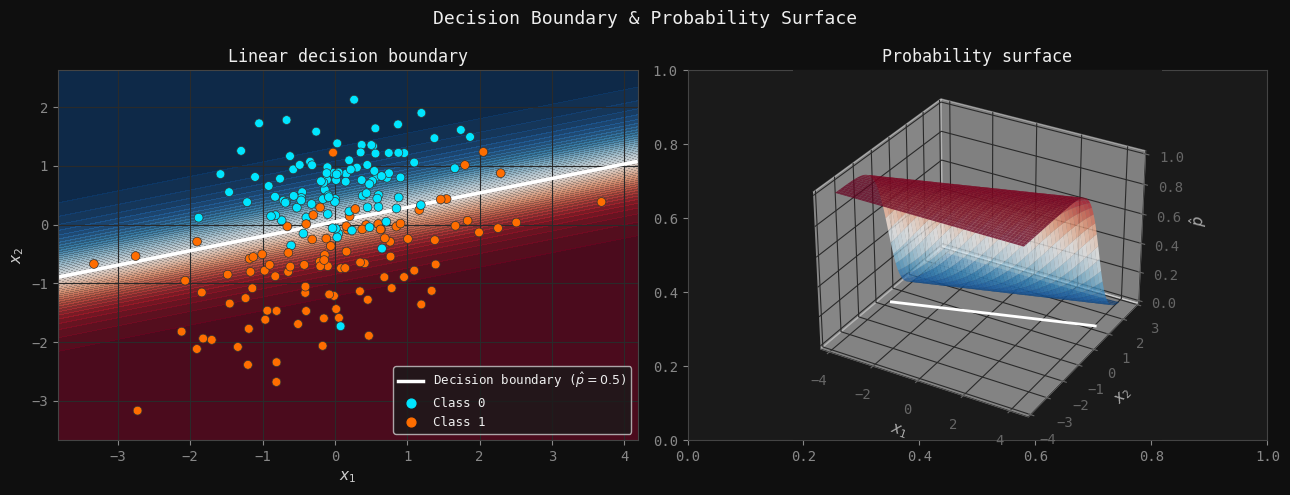

In [4]:
np.random.seed(1)
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                               n_informative=2, n_clusters_per_class=1, random_state=1)
scaler = StandardScaler().fit(X2)
X2s = scaler.transform(X2)

clf = LogisticRegression(C=1.0).fit(X2s, y2)

x_min, x_max = X2s[:,0].min()-0.5, X2s[:,0].max()+0.5
y_min, y_max = X2s[:,1].min()-0.5, X2s[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Decision Boundary & Probability Surface', fontsize=13)

# Decision boundary
ax = axes[0]
ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
ax.contour(xx,  yy, Z, levels=[0.5], colors='white', linewidths=2.5)
colors_cls = [ACCENT if yi==0 else ORANGE for yi in y2]
ax.scatter(X2s[:,0], X2s[:,1], c=colors_cls, s=40, edgecolors='#333', linewidth=0.5, zorder=5)
ax.plot([], [], color='white', lw=2.5, label='Decision boundary ($\\hat{p}=0.5$)')
ax.scatter([], [], color=ACCENT, s=40, label='Class 0')
ax.scatter([], [], color=ORANGE, s=40, label='Class 1')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Linear decision boundary')
ax.legend(fontsize=9); ax.grid(True)

# Probability surface 3D
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.set_facecolor('#1a1a1a')
ax2.plot_surface(xx, yy, Z, cmap='RdBu_r', alpha=0.75, linewidth=0)
ax2.contour(xx, yy, Z, levels=[0.5], zdir='z', offset=0, colors='white', linewidths=2)
ax2.set_xlabel('$x_1$', color='#aaa')
ax2.set_ylabel('$x_2$', color='#aaa')
ax2.set_zlabel('$\\hat{p}$', color='#aaa')
ax2.set_title('Probability surface', color='#eee')
ax2.tick_params(colors='#666')

plt.tight_layout()
plt.savefig('img/lr03_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Loss Function — Binary Cross-Entropy

Why not use MSE? Because with a sigmoid output, MSE creates a **non-convex** loss with many local minima — gradient descent gets stuck.

The right loss for probabilities is **binary cross-entropy** (log-loss):

$$\mathcal{L}(\theta) = -\frac{1}{n}\sum_{i=1}^n \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

For a single sample:
$$\ell(\theta; x_i, y_i) = \begin{cases} -\log(\hat{p}_i) & \text{if } y_i = 1 \\ -\log(1-\hat{p}_i) & \text{if } y_i = 0 \end{cases}$$

This can be rewritten compactly using the **log-sum-exp** trick:
$$\ell(\theta; x_i, y_i) = \log(1 + e^{-y_i^* \cdot x_i^\top\theta})$$
where $y_i^* = 2y_i - 1 \in \{-1, +1\}$.

**Why is log-loss convex?** Because $-\log(\sigma(z))$ and $-\log(1-\sigma(z))$ are both convex in $z$, and $z = x^\top\theta$ is linear in $\theta$ — and a convex function of a linear function is convex. This guarantees gradient descent finds the global minimum.

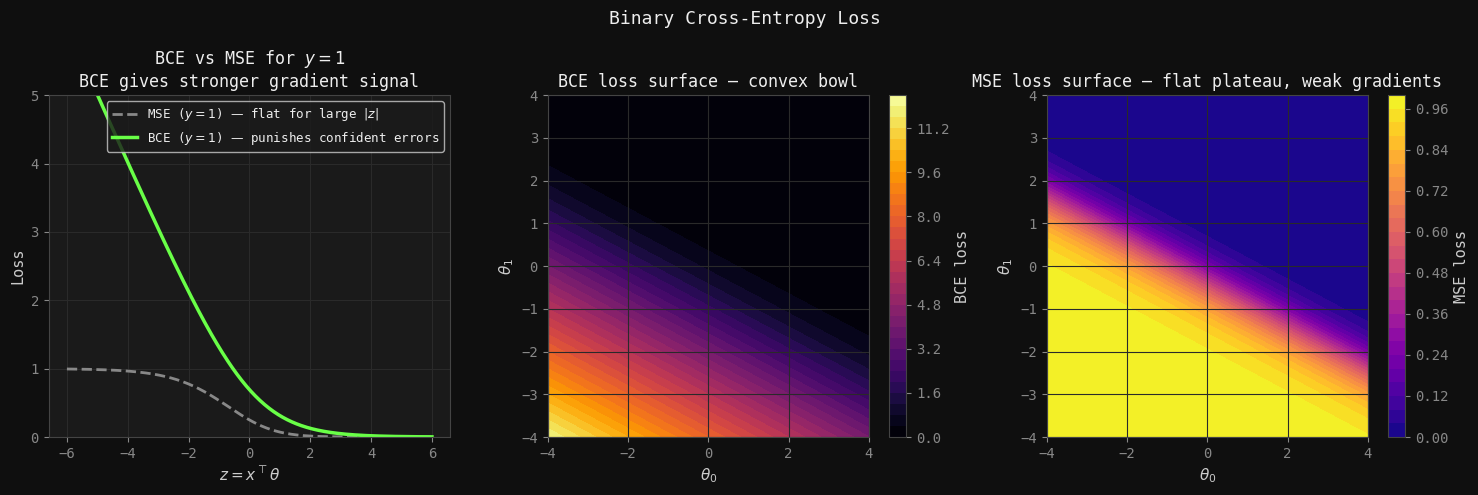

In [5]:
z_range = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Binary Cross-Entropy Loss', fontsize=13)

# MSE vs BCE on sigmoid output
ax = axes[0]
y_hat = sigmoid(z_range)
mse_y1  = (1 - y_hat)**2
mse_y0  = (0 - y_hat)**2
bce_y1  = -np.log(y_hat + 1e-9)
bce_y0  = -np.log(1 - y_hat + 1e-9)

ax.plot(z_range, mse_y1, color='#888', lw=2, linestyle='--', label='MSE ($y=1$) — flat for large $|z|$')
ax.plot(z_range, bce_y1, color=GREEN,  lw=2.5, label='BCE ($y=1$) — punishes confident errors')
ax.set_xlabel('$z = x^\\top\\theta$'); ax.set_ylabel('Loss')
ax.set_title('BCE vs MSE for $y=1$\nBCE gives stronger gradient signal')
ax.legend(fontsize=9); ax.set_ylim(0, 5); ax.grid(True)

# BCE surface (convex)
ax = axes[1]
theta_vals = np.linspace(-4, 4, 300)
x_ex = np.array([1.0, 2.0])  # one sample, 2 features
y_ex = 1
bce_surface = np.array([
    [-np.log(sigmoid(np.dot(x_ex, np.array([t0, t1])))) * y_ex
      - np.log(1 - sigmoid(np.dot(x_ex, np.array([t0, t1])))) * (1-y_ex)
     for t1 in theta_vals] for t0 in theta_vals
])
T0g, T1g = np.meshgrid(theta_vals, theta_vals)
im = ax.contourf(T0g, T1g, bce_surface.T, levels=30, cmap='inferno')
plt.colorbar(im, ax=ax, label='BCE loss')
ax.set_xlabel('$\\theta_0$'); ax.set_ylabel('$\\theta_1$')
ax.set_title('BCE loss surface — convex bowl')
ax.grid(True)

# Why MSE is non-convex with sigmoid
ax = axes[2]
mse_surface = np.array([
    [(sigmoid(np.dot(x_ex, np.array([t0, t1]))) - y_ex)**2
     for t1 in theta_vals] for t0 in theta_vals
])
im2 = ax.contourf(T0g, T1g, mse_surface.T, levels=30, cmap='plasma')
plt.colorbar(im2, ax=ax, label='MSE loss')
ax.set_xlabel('$\\theta_0$'); ax.set_ylabel('$\\theta_1$')
ax.set_title('MSE loss surface — flat plateau, weak gradients')
ax.grid(True)

plt.tight_layout()
plt.savefig('img/lr04_loss.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Maximum Likelihood Estimation

Logistic regression is a **probabilistic model**. We model:
$$P(y_i = 1 | x_i) = \hat{p}_i = \sigma(x_i^\top\theta)$$
$$P(y_i = 0 | x_i) = 1 - \hat{p}_i$$

Both cases can be unified:
$$P(y_i | x_i) = \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}$$

Assuming i.i.d. samples, the **likelihood** of the entire dataset:
$$\mathcal{L}(\theta) = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}$$

Taking logs (log is monotone — same maximum, much easier to work with):
$$\log \mathcal{L}(\theta) = \sum_{i=1}^n \left[ y_i \log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right]$$

**Maximising log-likelihood** is identical to **minimising cross-entropy loss** — log-loss is not an arbitrary choice, it is the principled MLE objective for a Bernoulli model.

Unlike linear regression, there is **no closed-form solution** — we must use iterative optimisation (gradient descent, BFGS, IRLS).

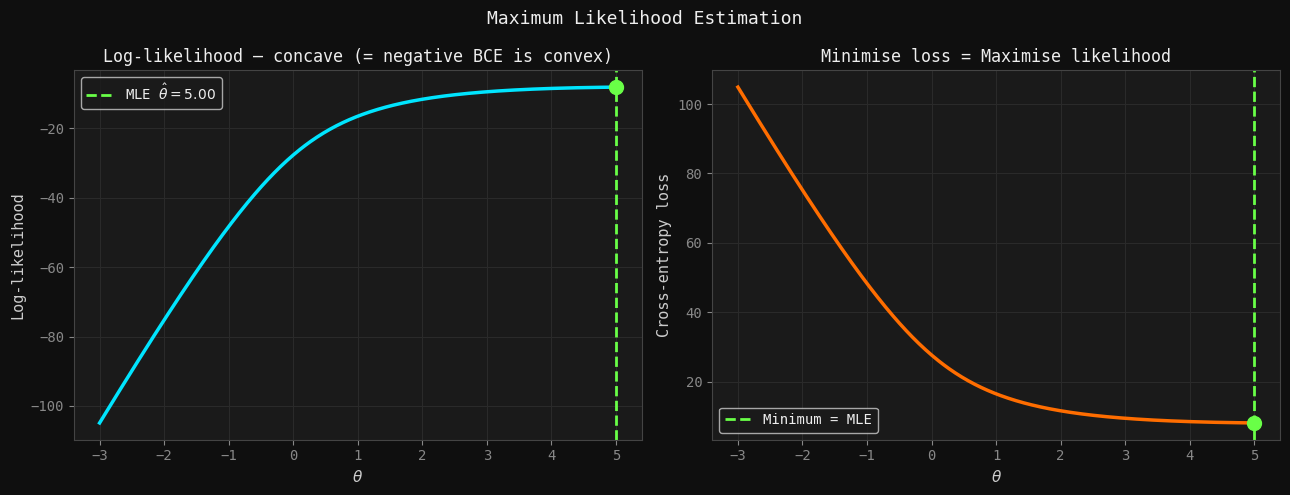

In [6]:
# Likelihood surface for a single parameter
np.random.seed(3)
n_mle = 40
x_mle = np.random.randn(n_mle)
y_mle = (x_mle * 1.5 + np.random.randn(n_mle) * 0.5 > 0).astype(float)

theta_range = np.linspace(-3, 5, 400)
log_likelihoods = []
for t in theta_range:
    p_hat = sigmoid(x_mle * t)
    ll = np.sum(y_mle * np.log(p_hat + 1e-10) + (1-y_mle) * np.log(1-p_hat + 1e-10))
    log_likelihoods.append(ll)
log_likelihoods = np.array(log_likelihoods)
best_theta = theta_range[np.argmax(log_likelihoods)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Maximum Likelihood Estimation', fontsize=13)

ax = axes[0]
ax.plot(theta_range, log_likelihoods, color=ACCENT, lw=2.5)
ax.axvline(best_theta, color=GREEN, lw=2, linestyle='--',
           label=f'MLE $\\hat{{\\theta}} = {best_theta:.2f}$')
ax.scatter(best_theta, max(log_likelihoods), color=GREEN, s=100, zorder=5)
ax.set_xlabel('$\\theta$'); ax.set_ylabel('Log-likelihood')
ax.set_title('Log-likelihood — concave (= negative BCE is convex)')
ax.legend(fontsize=10); ax.grid(True)

ax = axes[1]
ax.plot(theta_range, -log_likelihoods, color=ORANGE, lw=2.5)
ax.axvline(best_theta, color=GREEN, lw=2, linestyle='--', label=f'Minimum = MLE')
ax.scatter(best_theta, -max(log_likelihoods), color=GREEN, s=100, zorder=5)
ax.set_xlabel('$\\theta$'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Minimise loss = Maximise likelihood')
ax.legend(fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig('img/lr05_mle.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Gradient Descent on Log-Loss

The gradient of BCE loss with respect to $\theta$:

$$\nabla_\theta \mathcal{L} = \frac{1}{n} X^\top (\hat{p} - y)$$

where $\hat{p} = \sigma(X\theta) \in \mathbb{R}^n$ is the vector of predicted probabilities.

**Derivation sketch** (single sample):
$$\frac{\partial \ell}{\partial \theta_j} = -(y - \hat{p}) \cdot x_j$$

This follows from the chain rule:
$$\frac{\partial \ell}{\partial \theta_j} = \frac{\partial \ell}{\partial \hat{p}} \cdot \frac{\partial \hat{p}}{\partial z} \cdot \frac{\partial z}{\partial \theta_j}$$

where:
- $\frac{\partial \ell}{\partial \hat{p}} = -\frac{y}{\hat{p}} + \frac{1-y}{1-\hat{p}}$
- $\frac{\partial \hat{p}}{\partial z} = \sigma(z)(1-\sigma(z)) = \hat{p}(1-\hat{p})$ (sigmoid derivative)
- $\frac{\partial z}{\partial \theta_j} = x_j$

Multiplying these together: $\frac{\partial \ell}{\partial \theta_j} = (\hat{p} - y) x_j$.

The **elegant result**: the gradient of logistic regression has the same form as linear regression — it is the **error** $(\hat{p} - y)$ times the input $x$. The sigmoid derivative cancels out perfectly.

The update rule:
$$\theta \leftarrow \theta - \frac{\eta}{n} X^\top(\hat{p} - y)$$

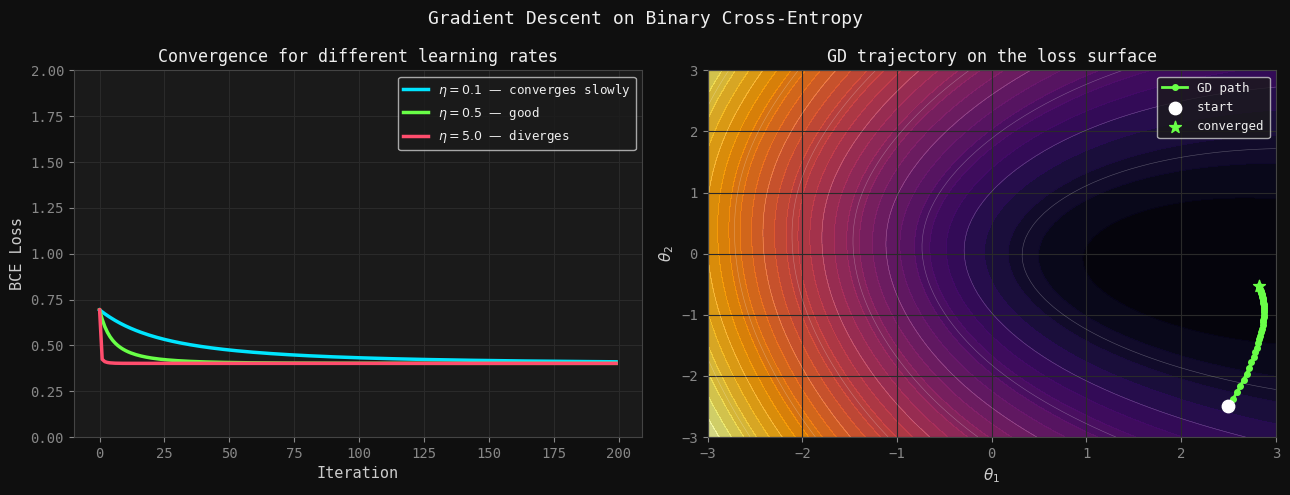

In [7]:
# Implement gradient descent from scratch and visualise convergence
np.random.seed(2)
X_gd, y_gd = make_classification(n_samples=150, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1, random_state=2)
X_gd = np.column_stack([np.ones(len(X_gd)), StandardScaler().fit_transform(X_gd)])

def bce_loss(theta, X, y):
    p = sigmoid(X @ theta)
    return -np.mean(y*np.log(p+1e-10) + (1-y)*np.log(1-p+1e-10))

def gd_step(theta, X, y, lr):
    p = sigmoid(X @ theta)
    grad = X.T @ (p - y) / len(y)
    return theta - lr * grad

theta_init = np.zeros(3)
history = {'sgd': [], 'lr01': [], 'lr10': []}
for lr, key in [(0.5, 'sgd'), (0.1, 'lr01'), (5.0, 'lr10')]:
    theta = theta_init.copy()
    for _ in range(200):
        history[key].append(bce_loss(theta, X_gd, y_gd))
        theta = gd_step(theta, X_gd, y_gd, lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gradient Descent on Binary Cross-Entropy', fontsize=13)

ax = axes[0]
ax.plot(history['lr01'], color=ACCENT,  lw=2.5, label='$\\eta=0.1$ — converges slowly')
ax.plot(history['sgd'],  color=GREEN,   lw=2.5, label='$\\eta=0.5$ — good')
ax.plot(history['lr10'], color=RED,     lw=2.5, label='$\\eta=5.0$ — diverges')
ax.set_xlabel('Iteration'); ax.set_ylabel('BCE Loss')
ax.set_title('Convergence for different learning rates')
ax.set_ylim(0, 2); ax.legend(fontsize=9); ax.grid(True)

# Gradient field on the loss surface
ax = axes[1]
t1_r = np.linspace(-3, 3, 60)
t2_r = np.linspace(-3, 3, 60)
T1g, T2g = np.meshgrid(t1_r, t2_r)
Loss_grid = np.array([[bce_loss(np.array([0, t1, t2]), X_gd, y_gd)
                        for t1 in t1_r] for t2 in t2_r])
ax.contourf(T1g, T2g, Loss_grid, levels=30, cmap='inferno', alpha=0.85)
ax.contour(T1g, T2g, Loss_grid, levels=15, colors='white', linewidths=0.4, alpha=0.3)
# GD path
theta_path = [np.array([0.0, 2.5, -2.5])]
t = theta_path[0].copy()
for _ in range(40):
    t = gd_step(t, X_gd, y_gd, 0.5)
    theta_path.append(t.copy())
path = np.array(theta_path)
ax.plot(path[:,1], path[:,2], color=GREEN, lw=2, marker='o', ms=4, label='GD path')
ax.scatter(*path[0, 1:3], color='white', s=80, zorder=6, label='start')
ax.scatter(*path[-1,1:3], color=GREEN,  s=80, zorder=6, marker='*', label='converged')
ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('$\\theta_2$')
ax.set_title('GD trajectory on the loss surface')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/lr06_gradient_descent.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Multiclass — Softmax

For $C > 2$ classes, logistic regression generalises to **Multinomial Logistic Regression** using the **softmax** function.

For each class $c$, we learn a weight vector $\theta_c \in \mathbb{R}^{p+1}$. The **logit** (score) for class $c$:
$$z_c = x^\top \theta_c$$

The **softmax** converts raw scores to probabilities:
$$\hat{p}_c = P(y=c|x) = \text{softmax}(z)_c = \frac{e^{z_c}}{\sum_{k=1}^C e^{z_k}}$$

Properties:
- All outputs in $(0,1)$ and sum to 1 — a valid probability distribution
- Amplifies differences between scores (larger scores dominate)
- Reduces to the sigmoid for $C=2$

**Numerical stability**: to prevent overflow in $e^{z_c}$, subtract the maximum score:
$$\text{softmax}(z)_c = \frac{e^{z_c - \max_k z_k}}{\sum_{k} e^{z_k - \max_k z_k}}$$

The loss is **categorical cross-entropy**:
$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^n \sum_{c=1}^C y_{ic} \log(\hat{p}_{ic})$$
where $y_{ic}$ is 1 if sample $i$ belongs to class $c$, 0 otherwise (one-hot encoding).

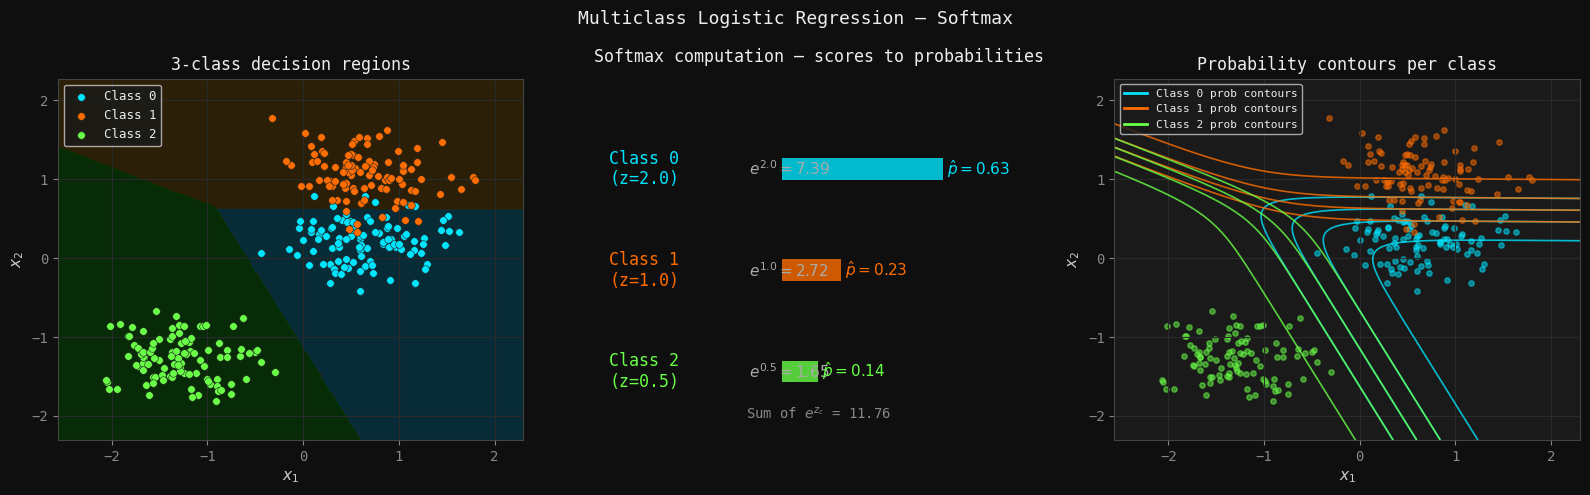

In [9]:
np.random.seed(4)
X3, y3 = make_blobs(n_samples=300, centers=3, n_features=2,
                     cluster_std=1.2, random_state=4)
sc3 = StandardScaler().fit(X3)
X3s = sc3.transform(X3)
clf3 = LogisticRegression(max_iter=1000).fit(X3s, y3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Multiclass Logistic Regression — Softmax', fontsize=13)

# Decision regions
ax = axes[0]
xx3, yy3 = np.meshgrid(np.linspace(X3s[:,0].min()-0.5, X3s[:,0].max()+0.5, 300),
                        np.linspace(X3s[:,1].min()-0.5, X3s[:,1].max()+0.5, 300))
Z3 = clf3.predict(np.c_[xx3.ravel(), yy3.ravel()]).reshape(xx3.shape)
cmap3 = ListedColormap(['#003344', '#332200', '#003300'])
ax.contourf(xx3, yy3, Z3, cmap=cmap3, alpha=0.7)
boundary_colors = [ACCENT, ORANGE, GREEN]
for cls, color in enumerate(boundary_colors):
    mask = y3 == cls
    ax.scatter(X3s[mask,0], X3s[mask,1], color=color, s=30,
               edgecolors='#222', linewidth=0.4, zorder=5, label=f'Class {cls}')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('3-class decision regions')
ax.legend(fontsize=9); ax.grid(True)

# Softmax on a concrete example
ax = axes[1]
ax.axis('off')
scores = np.array([2.0, 1.0, 0.5])
probs  = np.exp(scores) / np.exp(scores).sum()
labels_sm = ['Class 0\n(z=2.0)', 'Class 1\n(z=1.0)', 'Class 2\n(z=0.5)']
colors_sm = [ACCENT, ORANGE, GREEN]

# Draw as a diagram
for i, (lbl, prob, color) in enumerate(zip(labels_sm, probs, colors_sm)):
    y_pos = 0.75 - i*0.28
    ax.text(0.05, y_pos, lbl, transform=ax.transAxes, color=color,
            fontsize=12, va='center')
    ax.text(0.35, y_pos, f'$e^{{{scores[i]}}} = {np.exp(scores[i]):.2f}$',
            transform=ax.transAxes, color='#aaa', fontsize=11, va='center')
    bar_w = prob * 0.55
    ax.barh(y_pos, bar_w, 0.06, left=0.42, color=color, alpha=0.8,
            transform=ax.transAxes)
    ax.text(0.42 + bar_w + 0.01, y_pos,
            f'$\\hat{{p}}={prob:.2f}$',
            transform=ax.transAxes, color=color, fontsize=11, va='center')
ax.text(0.5, 0.06, f'Sum of $e^{{z_c}}$ = {np.exp(scores).sum():.2f}',
        transform=ax.transAxes, color='#888', fontsize=10, ha='center')
ax.set_title('Softmax computation — scores to probabilities', pad=12)

# Probability contours for each class
ax = axes[2]
prob_grid = clf3.predict_proba(np.c_[xx3.ravel(), yy3.ravel()]).reshape(*xx3.shape, 3)
for cls, color in enumerate(boundary_colors):
    ax.contour(xx3, yy3, prob_grid[:,:,cls],
               levels=[0.3, 0.5, 0.7, 0.9], colors=[color], linewidths=1.2, alpha=0.8)
    ax.plot([], [], color=color, lw=2, label=f'Class {cls} prob contours')
for cls, color in enumerate(boundary_colors):
    mask = y3 == cls
    ax.scatter(X3s[mask,0], X3s[mask,1], color=color, s=15, alpha=0.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Probability contours per class')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('img/lr07_softmax.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Regularisation

Logistic regression can overfit, especially when features are correlated or $p$ is large. Regularisation penalises the weights.

**L2 (Ridge) — the default**:
$$\mathcal{L}_{\text{ridge}} = -\frac{1}{n}\sum_i \ell_i + \frac{\lambda}{2}\|\theta\|^2$$
Gradient: adds $\lambda\theta$ — shrinks all weights toward zero without zeroing them.

In scikit-learn: `LogisticRegression(C=1/lambda)` — note **C is the inverse of regularisation strength**.

**L1 (Lasso)**:
$$\mathcal{L}_{\text{lasso}} = -\frac{1}{n}\sum_i \ell_i + \lambda\|\theta\|_1$$
Produces sparse weights — useful for feature selection.

**Effect on the decision boundary**: stronger regularisation ($\lambda$ ↑ = C ↓) makes the boundary smoother and more conservative — the model becomes less confident about predictions near the boundary.

**Probabilistic interpretation of L2**: it is equivalent to placing a Gaussian prior $\theta \sim \mathcal{N}(0, 1/\lambda)$ on the weights and doing **MAP** (Maximum A Posteriori) estimation instead of MLE.

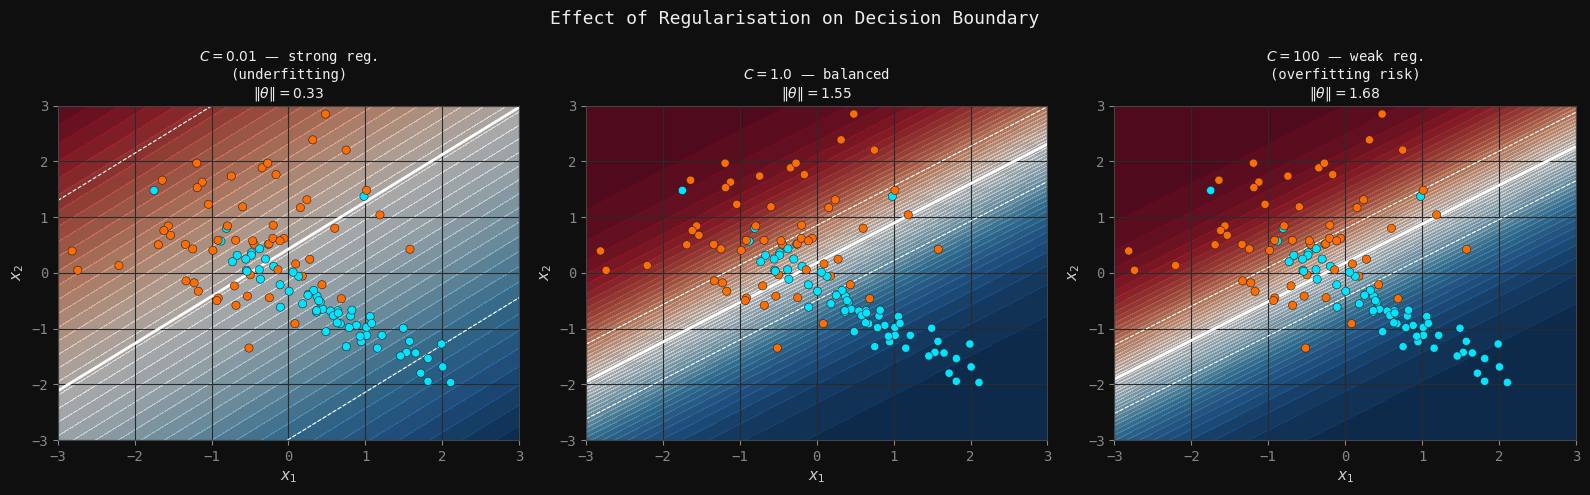

In [10]:
np.random.seed(7)
X_reg, y_reg = make_classification(n_samples=120, n_features=2, n_redundant=0,
                                     n_informative=2, n_clusters_per_class=1,
                                     class_sep=0.6, random_state=7)
X_regs = StandardScaler().fit_transform(X_reg)

C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Effect of Regularisation on Decision Boundary', fontsize=13)

xx_r, yy_r = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))

# Three representative C values
for ax, C, title in zip(axes,
                         [0.01, 1.0, 100.0],
                         ['$C=0.01$ — strong reg.\n(underfitting)',
                          '$C=1.0$ — balanced',
                          '$C=100$ — weak reg.\n(overfitting risk)']):
    clf_r = LogisticRegression(C=C, max_iter=1000).fit(X_regs, y_reg)
    Z_r   = clf_r.predict_proba(np.c_[xx_r.ravel(), yy_r.ravel()])[:,1].reshape(xx_r.shape)
    ax.contourf(xx_r, yy_r, Z_r, levels=50, cmap='RdBu_r', alpha=0.65)
    ax.contour(xx_r,  yy_r, Z_r, levels=[0.5], colors='white', linewidths=2)
    ax.contour(xx_r,  yy_r, Z_r, levels=[0.3, 0.7], colors='white', linewidths=0.8, linestyles='--')
    colors_c = [ACCENT if yi==0 else ORANGE for yi in y_reg]
    ax.scatter(X_regs[:,0], X_regs[:,1], c=colors_c, s=35,
               edgecolors='#222', linewidth=0.4, zorder=5)
    norm_w = np.linalg.norm(clf_r.coef_)
    ax.set_title(f'{title}\n$\\|\\theta\\|={norm_w:.2f}$', fontsize=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.grid(True)

plt.tight_layout()
plt.savefig('img/lr08_regularisation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Key Takeaways

1. Logistic regression predicts **probabilities** using $\hat{p} = \sigma(x^\top\theta)$ — it is a linear model in **log-odds space**.
2. The loss is **binary cross-entropy** — the principled MLE objective for a Bernoulli model, not an arbitrary choice.
3. Unlike linear regression, there is **no closed-form solution** — but the loss is convex, so gradient descent finds the global minimum.
4. The gradient $\nabla_\theta \mathcal{L} = \frac{1}{n}X^\top(\hat{p}-y)$ has the **same form as linear regression** — the sigmoid derivative cancels out.
5. Logistic regression is a **linear classifier** — it can only learn linear decision boundaries.
6. **Softmax** generalises sigmoid to $C > 2$ classes; categorical cross-entropy generalises log-loss.
7. **L2 regularisation** (C in sklearn) is equivalent to a Gaussian prior on weights — it is MAP estimation, not MLE.

---
*Previous: [`02_linear_regression.ipynb`](./02_linear_regression.ipynb) · Next: [`04_neural_networks_backprop.ipynb`](./04_neural_networks_backprop.ipynb)*